In [ ]:
from google.colab import files

# This will prompt you to select a file from your local machine
uploaded = files.upload()

# If you are uploading a CSV, you can then load it into Pandas like this:
import pandas as pd
import io

# Change 'your_file.csv' to the actual name of the file you uploaded
df = pd.read_csv(io.BytesIO(uploaded['your_file.csv']))
print(df.head())

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


KeyError: 'your_file.csv'

In [ ]:
import pandas as pd
import io

# Use the exact name of the file you just uploaded
df = pd.read_csv(io.BytesIO(uploaded['Titanic-Dataset.csv']))

# Display the first few rows to make sure it worked
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
# Drop the Cabin column because it has too much missing data
df.drop(columns=['Cabin'], inplace=True)

In [ ]:
# Fill missing Embarked values with the most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


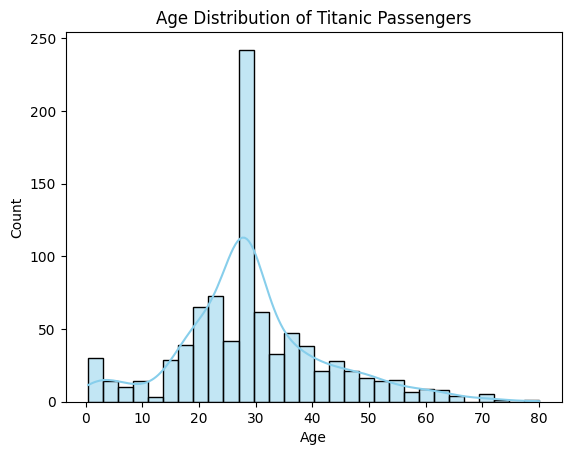

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a histogram of ages
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue')
plt.title('Age Distribution of Titanic Passengers')
plt.show()

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

# Now run describe again - the count should jump to 891!
print(df['Age'].describe())

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
# Fill the 2 missing Embarked values with the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Verify everything is now 0
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Instead of using inplace=True
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
# We will use Label Encoding
from sklearn.preprocessing import LabelEncoder
sexLe = LabelEncoder()
embarkedLe = LabelEncoder()

df['Sex'] = sexLe.fit_transform(df['Sex'])
df['Embarked'] = embarkedLe.fit_transform(df['Embarked'])

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


In [ ]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [ ]:
# Feature Scaling will not change the Distribution of Data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,0.271174,1,0,0.014151,2
1,1,1,0,0.472229,1,0,0.139136,0
2,1,3,0,0.321438,0,0,0.015469,2
3,1,1,0,0.434531,1,0,0.103644,2
4,0,3,1,0.434531,0,0,0.015713,2


In [ ]:
# Sample Inverse Transform
scaler.inverse_transform(df[['Age','Fare']].head())

array([[22.    ,  7.25  ],
       [38.    , 71.2833],
       [26.    ,  7.925 ],
       [35.    , 53.1   ],
       [35.    ,  8.05  ]])

In [ ]:
df.to_csv('Preprocessed_Titanic_Dataset.csv',index=False)

In [22]:
# Replace with your own GitHub details
!git config --global user.email "tybaasuleman@gmail.com"
!git config --global user.name "tybaasuleman-blip"

In [23]:
import os

# Set your variables
GITHUB_USER = 'tybaasuleman-blip'
REPO_NAME = 'Titanic datas set'

# Initialize and add files
!git init
!git add .
!git commit -m "Initial commit: Titanic Preprocessing"

# Push using your token for authentication
!git remote add origin https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git
!git branch -M main
!git push -u origin main

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
[master (root-commit) 281619c] Initial commit: Titanic Preprocessing
 23 files changed, 52843 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create